      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    

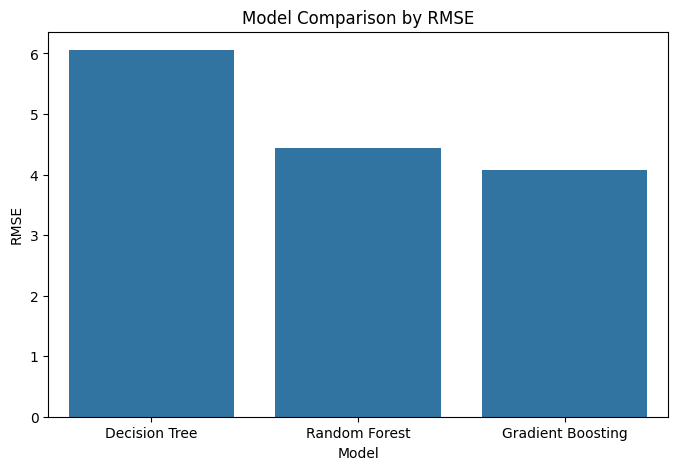

    Feature  Importance
5        RM    0.550359
12    LSTAT    0.298974
7       DIS    0.048146
0      CRIM    0.027263
4       NOX    0.020927
9       TAX    0.014430
10  PTRATIO    0.012659
6       AGE    0.011573
11        B    0.006992
2     INDUS    0.004357
8       RAD    0.003311
3      CHAS    0.000523
1        ZN    0.000488


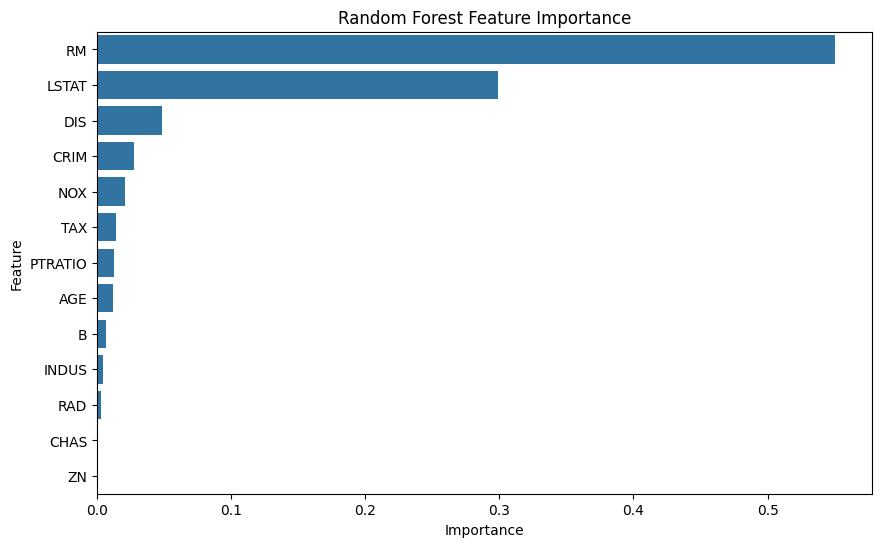

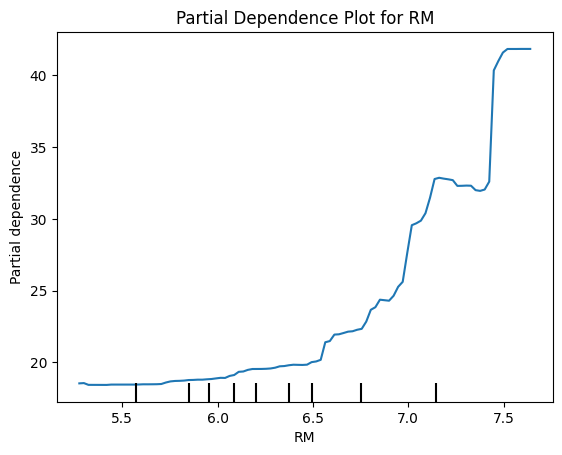

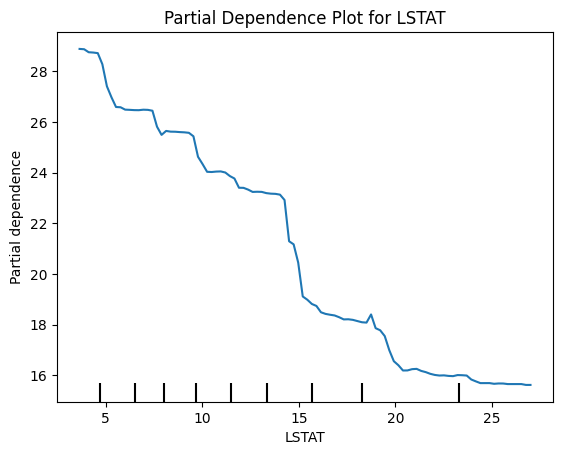

INFO:PyALE._ALE_generic:Continuous feature detected.


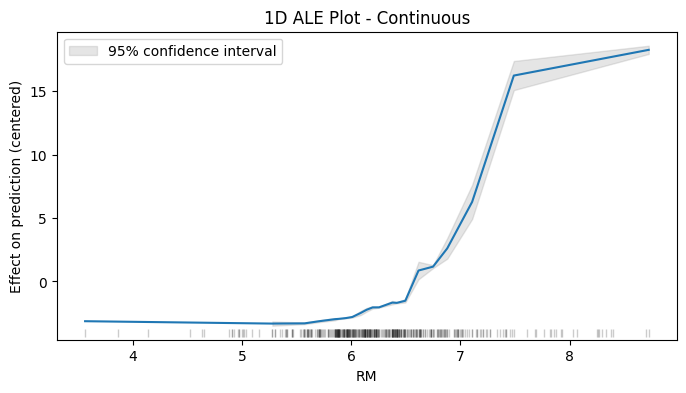

INFO:PyALE._ALE_generic:Continuous feature detected.


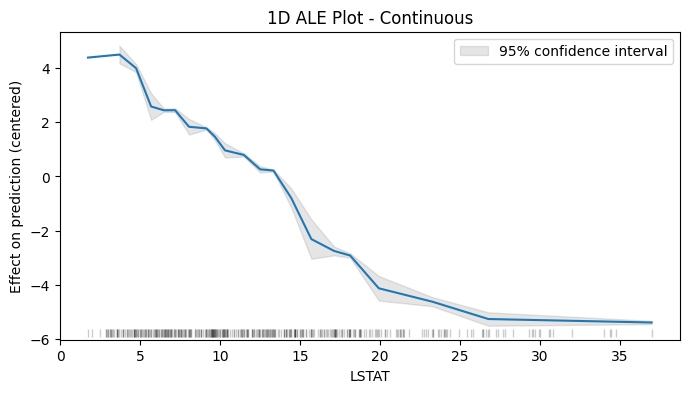

In [1]:
# ==========================================================
# QUMT 6350
# Week 6 Individual Assignment
#
# Name: Maximino Villanueva
# Professor: Professor Sun
# Dataset: Boston Housing
#
# Models Used:
# 1. Decision Tree
# 2. Random Forest
# 3. Gradient Boosting
# ==========================================================

# Install required package for ALE plots
!pip install PyALE

# Import pandas for data handling
import pandas as pd

# Import numpy for numerical work
import numpy as np

# Import matplotlib for plots
import matplotlib.pyplot as plt

# Import seaborn for optional visualization
import seaborn as sns

# Import the Boston Housing dataset source
from sklearn.datasets import fetch_openml

# Import train test split
from sklearn.model_selection import train_test_split

# Import grid search for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import decision tree model
from sklearn.tree import DecisionTreeRegressor

# Import random forest model
from sklearn.ensemble import RandomForestRegressor

# Import gradient boosting model
from sklearn.ensemble import GradientBoostingRegressor

# Import performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import partial dependence display
from sklearn.inspection import PartialDependenceDisplay

# Import ALE plot tool
from PyALE import ale

# Set random seed for reproducibility
np.random.seed(123)

# Load the Boston Housing dataset from OpenML
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Store predictors in X
X = boston.data

# Store target variable in y
y = boston.target.astype(float)

# Combine X and y into one dataframe for review
housing = X.copy()

# Add target variable to housing dataframe
housing["medv"] = y

# Display first five rows
print(housing.head())

# Check dataset information
print(housing.info())

# Check missing values
print(housing.isnull().sum())

# Convert all columns to numeric where possible
housing = housing.apply(pd.to_numeric, errors="coerce")

# Drop rows with missing values if any exist
housing = housing.dropna()

# Recreate X after cleaning
X = housing.drop("medv", axis=1)

# Recreate y after cleaning
y = housing["medv"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123
)

# Define evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    # Generate predictions
    predictions = model.predict(X_test)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    # Calculate MAE
    mae = mean_absolute_error(y_test, predictions)

    # Calculate R squared
    r2 = r2_score(y_test, predictions)

    # Print results
    print(model_name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R squared:", r2)
    print()

    # Return results as dictionary
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

# ==========================================================
# Model 1: Decision Tree
# ==========================================================

# Create decision tree model
tree = DecisionTreeRegressor(random_state=123)

# Define decision tree tuning grid
tree_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Tune decision tree using grid search
tree_search = GridSearchCV(
    estimator=tree,
    param_grid=tree_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit tuned decision tree
tree_search.fit(X_train, y_train)

# Save best decision tree model
best_tree = tree_search.best_estimator_

# Print best decision tree parameters
print("Best Decision Tree Parameters:")
print(tree_search.best_params_)

# Evaluate decision tree
tree_results = evaluate_model(best_tree, X_test, y_test, "Decision Tree")

# ==========================================================
# Model 2: Random Forest
# ==========================================================

# Create random forest model
rf = RandomForestRegressor(random_state=123)

# Define random forest tuning grid
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Tune random forest using grid search
rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit tuned random forest
rf_search.fit(X_train, y_train)

# Save best random forest model
best_rf = rf_search.best_estimator_

# Print best random forest parameters
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

# Evaluate random forest
rf_results = evaluate_model(best_rf, X_test, y_test, "Random Forest")

# ==========================================================
# Model 3: Gradient Boosting
# ==========================================================

# Create gradient boosting model
gb = GradientBoostingRegressor(random_state=123)

# Define gradient boosting tuning grid
gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.10],
    "max_depth": [2, 3, 4]
}

# Tune gradient boosting using grid search
gb_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit tuned gradient boosting model
gb_search.fit(X_train, y_train)

# Save best gradient boosting model
best_gb = gb_search.best_estimator_

# Print best gradient boosting parameters
print("Best Gradient Boosting Parameters:")
print(gb_search.best_params_)

# Evaluate gradient boosting
gb_results = evaluate_model(best_gb, X_test, y_test, "Gradient Boosting")

# ==========================================================
# Model Comparison
# ==========================================================

# Combine model results into dataframe
results_df = pd.DataFrame([tree_results, rf_results, gb_results])

# Print model comparison
print(results_df)

# Plot model comparison by RMSE
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

# Create feature importance dataframe for random forest
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

# Sort feature importance values
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Print feature importance
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ==========================================================
# Partial Dependence Plots
# ==========================================================

# Create partial dependence plot for rm
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=["RM"]
)
plt.title("Partial Dependence Plot for RM")
plt.show()

# Create partial dependence plot for lstat
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=["LSTAT"]
)
plt.title("Partial Dependence Plot for LSTAT")
plt.show()

# Interpretation comment for PDP
# The PDP for RM shows how predicted median home value changes as the average number of rooms changes.

# Interpretation comment for PDP
# The PDP for LSTAT shows how predicted median home value changes as the percentage of lower status population changes.

# ==========================================================
# ALE Plots
# ==========================================================

# Create ALE plot for RM
ale(
    X=X_train,
    model=best_rf,
    feature=["RM"],
    grid_size=20,
    include_CI=True
)

# Show ALE plot
plt.show()

# Create ALE plot for LSTAT
ale(
    X=X_train,
    model=best_rf,
    feature=["LSTAT"],
    grid_size=20,
    include_CI=True
)

# Show ALE plot
plt.show()

# Interpretation comment for ALE
# The ALE plot for RM shows the local effect of room count on predicted median home value.

# Interpretation comment for ALE
# The ALE plot for LSTAT shows the local effect of lower status percentage on predicted median home value.

# ==========================================================
# Final Interpretation
# ==========================================================

# Final interpretation comment
# The best model is usually the one with the lowest RMSE and highest R squared.

# Final interpretation comment
# Random Forest and Gradient Boosting are expected to perform better than a single Decision Tree.

# Final interpretation comment
# RM is expected to have a positive relationship with MEDV because homes with more rooms usually have higher values.

# Final interpretation comment
# LSTAT is expected to have a negative relationship with MEDV because neighborhoods with higher lower status percentages usually have lower home values.

# Final interpretation comment
# This assignment shows that model interpretation is important because accuracy alone does not explain why predictions are made.